In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import keras
from keras.layers import Input, Dense
from keras.models import Model
from keras import optimizers
from keras import losses
from keras import metrics

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, Matern, RationalQuadratic, DotProduct
from robust_kernels.sklearn_kernels import Tukey, Andrews, Huber, Cauchy
from sklearn.preprocessing import MinMaxScaler


## Tukey Kernel

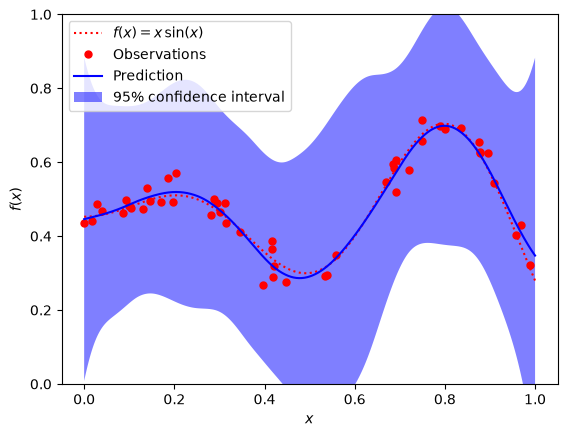

Test MSE: 0.001277488413136431


In [2]:
np.random.seed(1)

num_train_samples = 50

def f(x):
    """The function to predict."""
    return 10* x * np.sin(x*10)

x = np.atleast_2d(np.linspace(0, 1, 1000)).T

# Train and test data
X = np.random.random(2000)
X = np.atleast_2d(X).T

# Observations and noise
y = f(X).ravel()
dy = 0.5 + 1.0 * np.random.random(y.shape[0])
noise = np.random.normal(0, dy)
y += noise
scaler = MinMaxScaler((0.2, 0.8))
y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test = X[:num_train_samples], X[num_train_samples:]
y_train, y_test = y[:num_train_samples, None], y[num_train_samples:, None]

# Instantiate a Gaussian Process model
c = 0.3
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Tukey(c=c)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.15,# dy ** 2,
                              optimizer=None,)

# Fit to data using Maximum Likelihood Estimation of the parameters
gp.fit(X_train, y_train)

# Make the prediction on the meshed x-axis (ask for MSE as well)
y_pred, sigma = gp.predict(x, return_std=True)

# Plot the function, the prediction and the 95% confidence interval based on
# the MSE
plt.figure()
plt.plot(x, scaler.transform(f(x)), 'r:', label=r'$f(x) = x\,\sin(x)$')
plt.plot(X_train.ravel(), y_train, 'r.', markersize=10, label='Observations')
plt.plot(x, y_pred, 'b-', label='Prediction')
plt.fill_between(x[:,0], y_pred - 1.9600 * sigma, y_pred + 1.9600 * sigma,
         alpha=.5, fc='b', ec='None', label='95% confidence interval')

plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.ylim(0, 1)
plt.legend(loc='upper left')

plt.show()
y_pred_test = gp.predict(X_test)
from sklearn.metrics import mean_squared_error

print(f"Test MSE: {mean_squared_error(y_test, y_pred_test)}")

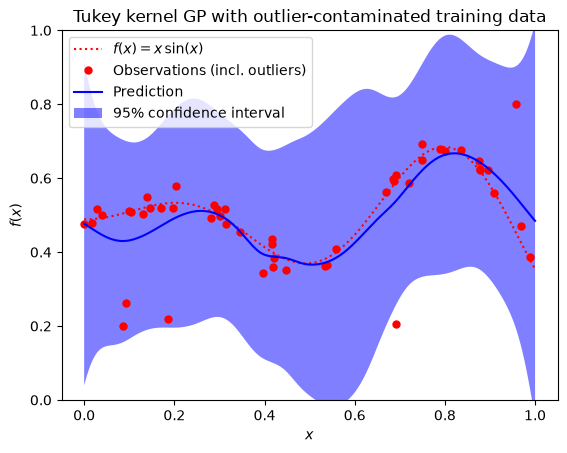

Test MSE: 0.0026843562898386936


In [3]:
np.random.seed(1)

num_train_samples = 50
contamination_fraction = 0.1  # fraction of training points corrupted with gross outliers

# Same data-generating process as before
X = np.random.random(2000)
X = np.atleast_2d(X).T

y = f(X).ravel()
dy = 0.5 + 1.0 * np.random.random(y.shape[0])
noise = np.random.normal(0, dy)
y += noise

# Inject outlier contamination into a subset of the training observations
n_outliers = int(contamination_fraction * num_train_samples)
outlier_idx = np.random.choice(num_train_samples, n_outliers, replace=False)
y[outlier_idx] += np.random.choice([-1, 1], n_outliers) * np.random.uniform(8, 15, n_outliers)

scaler = MinMaxScaler((0.2, 0.8))
y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test = X[:num_train_samples], X[num_train_samples:]
y_train, y_test = y[:num_train_samples, None], y[num_train_samples:, None]

# Instantiate a Gaussian Process model with the Tukey kernel
c = 0.3
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Tukey(c=c)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.15,
                              optimizer=None,)

# Fit to the outlier-contaminated data
gp.fit(X_train, y_train)

# Make the prediction on the meshed x-axis (ask for MSE as well)
y_pred, sigma = gp.predict(x, return_std=True)

# Plot the function, the prediction and the 95% confidence interval based on
# the MSE
plt.figure()
plt.plot(x, scaler.transform(f(x)), 'r:', label=r'$f(x) = x\,\sin(x)$')
plt.plot(X_train.ravel(), y_train, 'r.', markersize=10, label='Observations (incl. outliers)')
plt.plot(x, y_pred, 'b-', label='Prediction')
plt.fill_between(x[:,0], y_pred - 1.9600 * sigma, y_pred + 1.9600 * sigma,
         alpha=.5, fc='b', ec='None', label='95% confidence interval')

plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.ylim(0, 1)
plt.legend(loc='upper left')
plt.title('Tukey kernel GP with outlier-contaminated training data')

plt.show()
y_pred_test = gp.predict(X_test)
from sklearn.metrics import mean_squared_error

print(f"Test MSE: {mean_squared_error(y_test, y_pred_test)}")


## Andrews Kernel

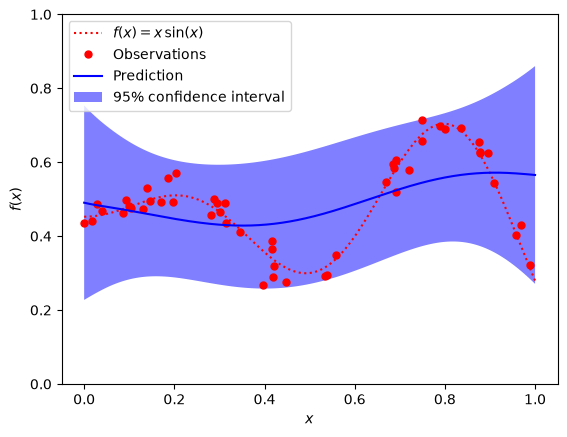

Test MSE: 0.010802166325514038


In [9]:
np.random.seed(1)

num_train_samples = 50

def f(x):
    """The function to predict."""
    return 10* x * np.sin(x*10)

x = np.atleast_2d(np.linspace(0, 1, 1000)).T

# Train and test data
X = np.random.random(2000)
X = np.atleast_2d(X).T

# Observations and noise
y = f(X).ravel()
dy = 0.5 + 1.0 * np.random.random(y.shape[0])
noise = np.random.normal(0, dy)
y += noise
scaler = MinMaxScaler((0.2, 0.8))
y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test = X[:num_train_samples], X[num_train_samples:]
y_train, y_test = y[:num_train_samples, None], y[num_train_samples:, None]

# Instantiate a Gaussian Process model
c = 0.3
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Andrews(c=c)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.15,# dy ** 2,
                              optimizer=None,)

# Fit to data using Maximum Likelihood Estimation of the parameters
gp.fit(X_train, y_train)

# Make the prediction on the meshed x-axis (ask for MSE as well)
y_pred, sigma = gp.predict(x, return_std=True)

# Plot the function, the prediction and the 95% confidence interval based on
# the MSE
plt.figure()
plt.plot(x, scaler.transform(f(x)), 'r:', label=r'$f(x) = x\,\sin(x)$')
plt.plot(X_train.ravel(), y_train, 'r.', markersize=10, label='Observations')
plt.plot(x, y_pred, 'b-', label='Prediction')
plt.fill_between(x[:,0], y_pred - 1.9600 * sigma, y_pred + 1.9600 * sigma,
         alpha=.5, fc='b', ec='None', label='95% confidence interval')

plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.ylim(0, 1)
plt.legend(loc='upper left')

plt.show()
y_pred_test = gp.predict(X_test)
from sklearn.metrics import mean_squared_error

print(f"Test MSE: {mean_squared_error(y_test, y_pred_test)}")

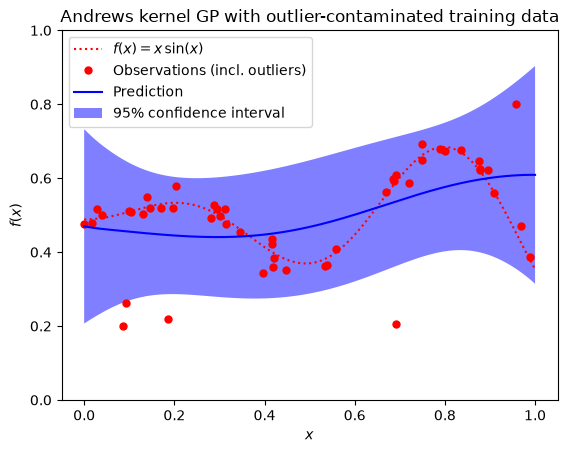

Test MSE: 0.007448465063913432


In [12]:
np.random.seed(1)

num_train_samples = 50
contamination_fraction = 0.1  # fraction of training points corrupted with gross outliers

# Same data-generating process as before
X = np.random.random(2000)
X = np.atleast_2d(X).T

y = f(X).ravel()
dy = 0.5 + 1.0 * np.random.random(y.shape[0])
noise = np.random.normal(0, dy)
y += noise

# Inject outlier contamination into a subset of the training observations
n_outliers = int(contamination_fraction * num_train_samples)
outlier_idx = np.random.choice(num_train_samples, n_outliers, replace=False)
y[outlier_idx] += np.random.choice([-1, 1], n_outliers) * np.random.uniform(8, 15, n_outliers)

scaler = MinMaxScaler((0.2, 0.8))
y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test = X[:num_train_samples], X[num_train_samples:]
y_train, y_test = y[:num_train_samples, None], y[num_train_samples:, None]

# Instantiate a Gaussian Process model with the Andrews kernel
c = 0.3
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Andrews(c=c)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.15,
                              optimizer=None,)

# Fit to the outlier-contaminated data
gp.fit(X_train, y_train)

# Make the prediction on the meshed x-axis (ask for MSE as well)
y_pred, sigma = gp.predict(x, return_std=True)

# Plot the function, the prediction and the 95% confidence interval based on
# the MSE
plt.figure()
plt.plot(x, scaler.transform(f(x)), 'r:', label=r'$f(x) = x\,\sin(x)$')
plt.plot(X_train.ravel(), y_train, 'r.', markersize=10, label='Observations (incl. outliers)')
plt.plot(x, y_pred, 'b-', label='Prediction')
plt.fill_between(x[:,0], y_pred - 1.9600 * sigma, y_pred + 1.9600 * sigma,
         alpha=.5, fc='b', ec='None', label='95% confidence interval')

plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.ylim(0, 1)
plt.legend(loc='upper left')
plt.title('Andrews kernel GP with outlier-contaminated training data')

plt.show()
y_pred_test = gp.predict(X_test)
from sklearn.metrics import mean_squared_error

print(f"Test MSE: {mean_squared_error(y_test, y_pred_test)}")


## Huber Kernel

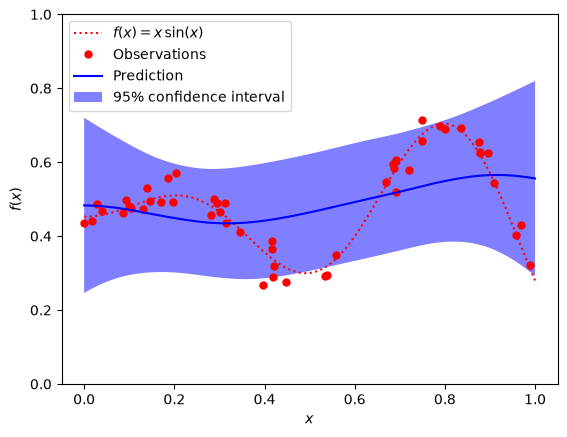

Test MSE: 0.011642124280004046


In [10]:
np.random.seed(1)

num_train_samples = 50

def f(x):
    """The function to predict."""
    return 10* x * np.sin(x*10)

x = np.atleast_2d(np.linspace(0, 1, 1000)).T

# Train and test data
X = np.random.random(2000)
X = np.atleast_2d(X).T

# Observations and noise
y = f(X).ravel()
dy = 0.5 + 1.0 * np.random.random(y.shape[0])
noise = np.random.normal(0, dy)
y += noise
scaler = MinMaxScaler((0.2, 0.8))
y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test = X[:num_train_samples], X[num_train_samples:]
y_train, y_test = y[:num_train_samples, None], y[num_train_samples:, None]

# Instantiate a Gaussian Process model
c = 0.3
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Huber(c=c)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.15,# dy ** 2,
                              optimizer=None,)

# Fit to data using Maximum Likelihood Estimation of the parameters
gp.fit(X_train, y_train)

# Make the prediction on the meshed x-axis (ask for MSE as well)
y_pred, sigma = gp.predict(x, return_std=True)

# Plot the function, the prediction and the 95% confidence interval based on
# the MSE
plt.figure()
plt.plot(x, scaler.transform(f(x)), 'r:', label=r'$f(x) = x\,\sin(x)$')
plt.plot(X_train.ravel(), y_train, 'r.', markersize=10, label='Observations')
plt.plot(x, y_pred, 'b-', label='Prediction')
plt.fill_between(x[:,0], y_pred - 1.9600 * sigma, y_pred + 1.9600 * sigma,
         alpha=.5, fc='b', ec='None', label='95% confidence interval')

plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.ylim(0, 1)
plt.legend(loc='upper left')

plt.show()
y_pred_test = gp.predict(X_test)
from sklearn.metrics import mean_squared_error

print(f"Test MSE: {mean_squared_error(y_test, y_pred_test)}")

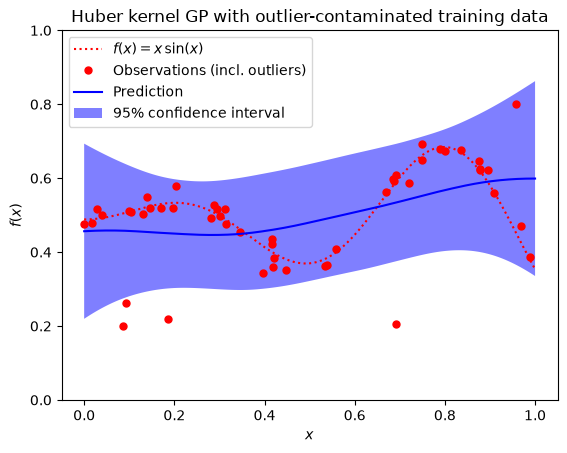

Test MSE: 0.007684955007553684


In [13]:
np.random.seed(1)

num_train_samples = 50
contamination_fraction = 0.1  # fraction of training points corrupted with gross outliers

# Same data-generating process as before
X = np.random.random(2000)
X = np.atleast_2d(X).T

y = f(X).ravel()
dy = 0.5 + 1.0 * np.random.random(y.shape[0])
noise = np.random.normal(0, dy)
y += noise

# Inject outlier contamination into a subset of the training observations
n_outliers = int(contamination_fraction * num_train_samples)
outlier_idx = np.random.choice(num_train_samples, n_outliers, replace=False)
y[outlier_idx] += np.random.choice([-1, 1], n_outliers) * np.random.uniform(8, 15, n_outliers)

scaler = MinMaxScaler((0.2, 0.8))
y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test = X[:num_train_samples], X[num_train_samples:]
y_train, y_test = y[:num_train_samples, None], y[num_train_samples:, None]

# Instantiate a Gaussian Process model with the Huber kernel
c = 0.3
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Huber(c=c)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.15,
                              optimizer=None,)

# Fit to the outlier-contaminated data
gp.fit(X_train, y_train)

# Make the prediction on the meshed x-axis (ask for MSE as well)
y_pred, sigma = gp.predict(x, return_std=True)

# Plot the function, the prediction and the 95% confidence interval based on
# the MSE
plt.figure()
plt.plot(x, scaler.transform(f(x)), 'r:', label=r'$f(x) = x\,\sin(x)$')
plt.plot(X_train.ravel(), y_train, 'r.', markersize=10, label='Observations (incl. outliers)')
plt.plot(x, y_pred, 'b-', label='Prediction')
plt.fill_between(x[:,0], y_pred - 1.9600 * sigma, y_pred + 1.9600 * sigma,
         alpha=.5, fc='b', ec='None', label='95% confidence interval')

plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.ylim(0, 1)
plt.legend(loc='upper left')
plt.title('Huber kernel GP with outlier-contaminated training data')

plt.show()
y_pred_test = gp.predict(X_test)
from sklearn.metrics import mean_squared_error

print(f"Test MSE: {mean_squared_error(y_test, y_pred_test)}")


## Cauchy Kernel

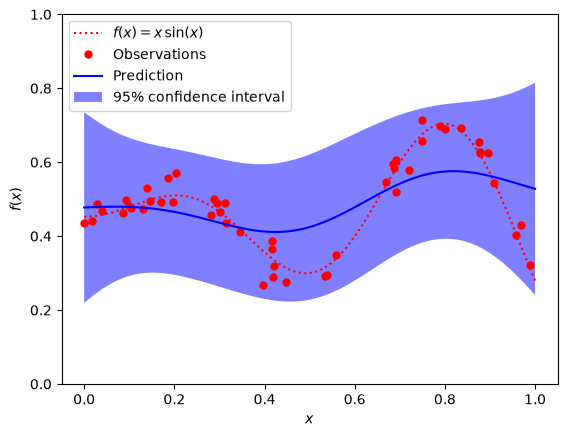

Test MSE: 0.008051809764580448


In [11]:
np.random.seed(1)

num_train_samples = 50

def f(x):
    """The function to predict."""
    return 10* x * np.sin(x*10)

x = np.atleast_2d(np.linspace(0, 1, 1000)).T

# Train and test data
X = np.random.random(2000)
X = np.atleast_2d(X).T

# Observations and noise
y = f(X).ravel()
dy = 0.5 + 1.0 * np.random.random(y.shape[0])
noise = np.random.normal(0, dy)
y += noise
scaler = MinMaxScaler((0.2, 0.8))
y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test = X[:num_train_samples], X[num_train_samples:]
y_train, y_test = y[:num_train_samples, None], y[num_train_samples:, None]

# Instantiate a Gaussian Process model
c = 0.3
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Cauchy(c=c)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.15,# dy ** 2,
                              optimizer=None,)

# Fit to data using Maximum Likelihood Estimation of the parameters
gp.fit(X_train, y_train)

# Make the prediction on the meshed x-axis (ask for MSE as well)
y_pred, sigma = gp.predict(x, return_std=True)

# Plot the function, the prediction and the 95% confidence interval based on
# the MSE
plt.figure()
plt.plot(x, scaler.transform(f(x)), 'r:', label=r'$f(x) = x\,\sin(x)$')
plt.plot(X_train.ravel(), y_train, 'r.', markersize=10, label='Observations')
plt.plot(x, y_pred, 'b-', label='Prediction')
plt.fill_between(x[:,0], y_pred - 1.9600 * sigma, y_pred + 1.9600 * sigma,
         alpha=.5, fc='b', ec='None', label='95% confidence interval')

plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.ylim(0, 1)
plt.legend(loc='upper left')

plt.show()
y_pred_test = gp.predict(X_test)
from sklearn.metrics import mean_squared_error

print(f"Test MSE: {mean_squared_error(y_test, y_pred_test)}")

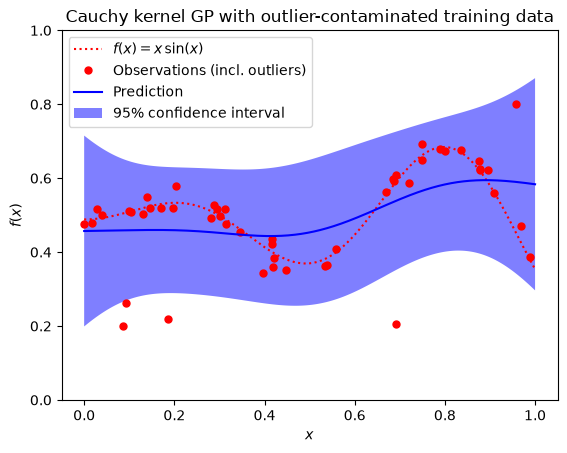

Test MSE: 0.0060122441632063876


In [14]:
np.random.seed(1)

num_train_samples = 50
contamination_fraction = 0.1  # fraction of training points corrupted with gross outliers

# Same data-generating process as before
X = np.random.random(2000)
X = np.atleast_2d(X).T

y = f(X).ravel()
dy = 0.5 + 1.0 * np.random.random(y.shape[0])
noise = np.random.normal(0, dy)
y += noise

# Inject outlier contamination into a subset of the training observations
n_outliers = int(contamination_fraction * num_train_samples)
outlier_idx = np.random.choice(num_train_samples, n_outliers, replace=False)
y[outlier_idx] += np.random.choice([-1, 1], n_outliers) * np.random.uniform(8, 15, n_outliers)

scaler = MinMaxScaler((0.2, 0.8))
y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test = X[:num_train_samples], X[num_train_samples:]
y_train, y_test = y[:num_train_samples, None], y[num_train_samples:, None]

# Instantiate a Gaussian Process model with the Cauchy kernel
c = 0.3
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Cauchy(c=c)
gp = GaussianProcessRegressor(kernel=kernel, alpha=0.15,
                              optimizer=None,)

# Fit to the outlier-contaminated data
gp.fit(X_train, y_train)

# Make the prediction on the meshed x-axis (ask for MSE as well)
y_pred, sigma = gp.predict(x, return_std=True)

# Plot the function, the prediction and the 95% confidence interval based on
# the MSE
plt.figure()
plt.plot(x, scaler.transform(f(x)), 'r:', label=r'$f(x) = x\,\sin(x)$')
plt.plot(X_train.ravel(), y_train, 'r.', markersize=10, label='Observations (incl. outliers)')
plt.plot(x, y_pred, 'b-', label='Prediction')
plt.fill_between(x[:,0], y_pred - 1.9600 * sigma, y_pred + 1.9600 * sigma,
         alpha=.5, fc='b', ec='None', label='95% confidence interval')

plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.ylim(0, 1)
plt.legend(loc='upper left')
plt.title('Cauchy kernel GP with outlier-contaminated training data')

plt.show()
y_pred_test = gp.predict(X_test)
from sklearn.metrics import mean_squared_error

print(f"Test MSE: {mean_squared_error(y_test, y_pred_test)}")


In [20]:
import pandas as pd
from sklearn.metrics import mean_squared_error

# Reuse the dataset-generation pattern already used in the notebook
def make_dataset(contamination_fraction=0.0, seed=1):
    np.random.seed(seed)
    num_train_samples = 50

    X = np.random.random(2000)
    X = np.atleast_2d(X).T

    y = f(X).ravel()
    dy = 0.5 + 1.0 * np.random.random(y.shape[0])
    noise = np.random.normal(0, dy)
    y += noise

    if contamination_fraction > 0:
        n_outliers = int(contamination_fraction * num_train_samples)
        outlier_idx = np.random.choice(num_train_samples, n_outliers, replace=False)
        y[outlier_idx] += np.random.choice([-1, 1], n_outliers) * np.random.uniform(8, 15, n_outliers)

    scaler = MinMaxScaler((0.2, 0.8))
    y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

    X_train, X_test = X[:num_train_samples], X[num_train_samples:]
    y_train, y_test = y[:num_train_samples, None], y[num_train_samples:, None]
    return X_train, X_test, y_train, y_test

kernel_builders = {
    "Tukey": lambda c: ConstantKernel(1.0, (1e-3, 1e3)) * Tukey(c=c, gamma=1.0),
    "Andrews": lambda c: ConstantKernel(1.0, (1e-3, 1e3)) * Andrews(c=c, gamma=1.0),
    "Huber": lambda c: ConstantKernel(1.0, (1e-3, 1e3)) * Huber(c=c, gamma=1.0),
    "Cauchy": lambda c: ConstantKernel(1.0, (1e-3, 1e3)) * Cauchy(c=c, gamma=1.0),
}

records = []

for contamination in [0.0, 0.1]:
    X_train, X_test, y_train, y_test = make_dataset(contamination_fraction=contamination, seed=1)
    for kernel_name, build_kernel in kernel_builders.items():
        kernel = build_kernel(0.3)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=0.15, optimizer=None)
        gp.fit(X_train, y_train)
        y_pred_test = gp.predict(X_test)
        mse = mean_squared_error(y_test, y_pred_test)
        records.append({
            "Kernel": kernel_name,
            "Contamination": contamination,
            "MSE": mse
        })

mse_table = (
    pd.DataFrame(records)
      .pivot(index="Kernel", columns="Contamination", values="MSE")
      .rename(columns={0.0: "0%", 0.1: "10%"})
)

mse_table

Contamination,0%,10%
Kernel,,
Andrews,0.010802,0.007448
Cauchy,0.008052,0.006012
Huber,0.011642,0.007685
Tukey,0.001277,0.002684


## Kernel Comparison

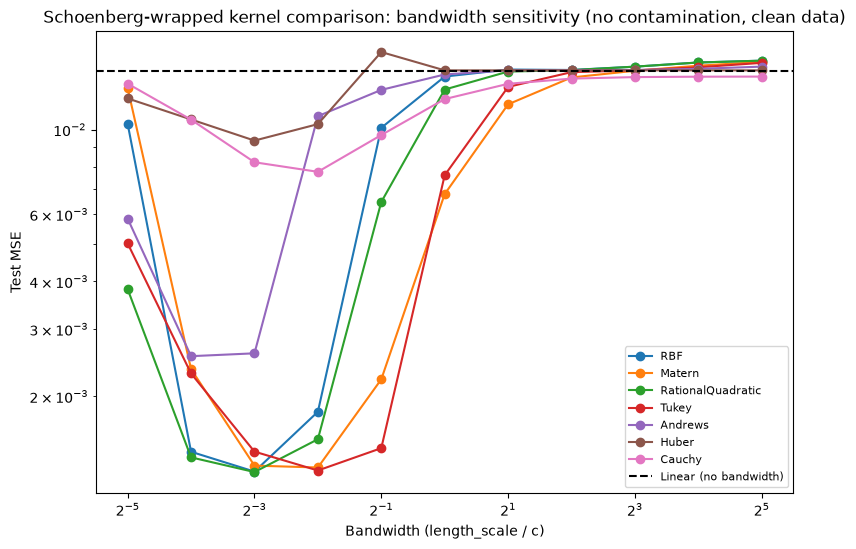

RBF
  bandwidth=   0.03125: MSE=0.01035
  bandwidth=   0.06250: MSE=0.00143
  bandwidth=   0.12500: MSE=0.00127
  bandwidth=   0.25000: MSE=0.00182
  bandwidth=   0.50000: MSE=0.01011
  bandwidth=   1.00000: MSE=0.01377
  bandwidth=   2.00000: MSE=0.01437
  bandwidth=   4.00000: MSE=0.01433
  bandwidth=   8.00000: MSE=0.01462
  bandwidth=  16.00000: MSE=0.01499
  bandwidth=  32.00000: MSE=0.01516
Matern
  bandwidth=   0.03125: MSE=0.01284
  bandwidth=   0.06250: MSE=0.00236
  bandwidth=   0.12500: MSE=0.00132
  bandwidth=   0.25000: MSE=0.00130
  bandwidth=   0.50000: MSE=0.00222
  bandwidth=   1.00000: MSE=0.00678
  bandwidth=   2.00000: MSE=0.01165
  bandwidth=   4.00000: MSE=0.01370
  bandwidth=   8.00000: MSE=0.01426
  bandwidth=  16.00000: MSE=0.01470
  bandwidth=  32.00000: MSE=0.01504
RationalQuadratic
  bandwidth=   0.03125: MSE=0.00382
  bandwidth=   0.06250: MSE=0.00138
  bandwidth=   0.12500: MSE=0.00127
  bandwidth=   0.25000: MSE=0.00154
  bandwidth=   0.50000: MSE=0.00646

In [6]:
# Schoenberg-wrapped kernel comparison: RBF, Matern, RationalQuadratic, Linear,
# and the four Schoenberg-wrapped robust kernels (Tukey, Andrews, Huber, Cauchy),
# on no contamination, clean data.

np.random.seed(1)

num_train_samples = 50
contamination_fraction = 0.0

X = np.random.random(2000)
X = np.atleast_2d(X).T

y = f(X).ravel()
dy = 0.5 + 1.0 * np.random.random(y.shape[0])
noise = np.random.normal(0, dy)
y += noise

n_outliers = int(contamination_fraction * num_train_samples)
outlier_idx = np.random.choice(num_train_samples, n_outliers, replace=False)
y[outlier_idx] += np.random.choice([-1, 1], n_outliers) * np.random.uniform(8, 15, n_outliers)

scaler = MinMaxScaler((0.2, 0.8))
y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test = X[:num_train_samples], X[num_train_samples:]
y_train, y_test = y[:num_train_samples, None], y[num_train_samples:, None]

from sklearn.metrics import mean_squared_error

bandwidths = [2.0 ** k for k in range(-5, 6)]
gamma = 1.0

kernel_builders = {
    "RBF": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=bw),
    "Matern": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=bw, nu=1.5),
    "RationalQuadratic": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * RationalQuadratic(length_scale=bw, alpha=1.0),
    "Tukey": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Tukey(c=bw, gamma=gamma),
    "Andrews": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Andrews(c=bw, gamma=gamma),
    "Huber": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Huber(c=bw, gamma=gamma),
    "Cauchy": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Cauchy(c=bw, gamma=gamma),
}

results = {name: [] for name in kernel_builders}

for name, build_kernel in kernel_builders.items():
    for bw in bandwidths:
        kernel = build_kernel(bw)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=0.15, optimizer=None)
        try:
            gp.fit(X_train, y_train)
            y_pred_test = gp.predict(X_test)
            mse = mean_squared_error(y_test, y_pred_test)
        except np.linalg.LinAlgError:
            mse = np.nan
        results[name].append(mse)

# Linear (DotProduct) kernel has no bandwidth/length_scale to sweep -- it's
# evaluated once and shown as a flat reference line instead.
linear_kernel = ConstantKernel(1.0, (1e-3, 1e3)) * DotProduct(sigma_0=1.0)
gp_linear = GaussianProcessRegressor(kernel=linear_kernel, alpha=0.15, optimizer=None)
gp_linear.fit(X_train, y_train)
linear_mse = mean_squared_error(y_test, gp_linear.predict(X_test))

plt.figure(figsize=(9, 6))
for name, mses in results.items():
    plt.plot(bandwidths, mses, marker='o', label=name)
plt.axhline(linear_mse, color='black', linestyle='--', label='Linear (no bandwidth)')

plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Bandwidth (length_scale / c)')
plt.ylabel('Test MSE')
plt.title('Schoenberg-wrapped kernel comparison: bandwidth sensitivity (no contamination, clean data)')
plt.legend(fontsize=8)
plt.show()

for name, mses in results.items():
    print(name)
    for bw, mse in zip(bandwidths, mses):
        mse_str = f"{mse:.5f}" if not np.isnan(mse) else "nan (singular kernel matrix)"
        print(f"  bandwidth={bw:>10.5f}: MSE={mse_str}")

print(f"Linear (no bandwidth): MSE={linear_mse:.5f}")

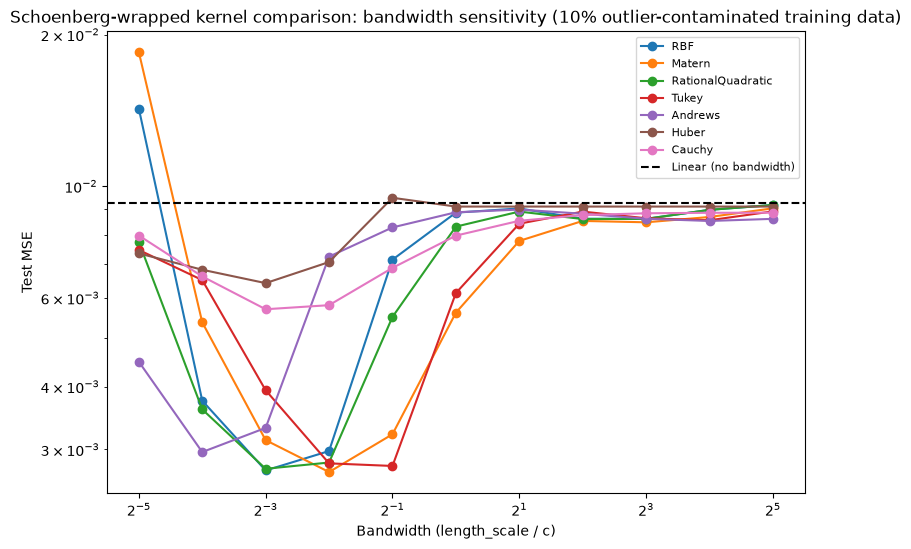

RBF
  bandwidth=   0.03125: MSE=0.01425
  bandwidth=   0.06250: MSE=0.00375
  bandwidth=   0.12500: MSE=0.00273
  bandwidth=   0.25000: MSE=0.00298
  bandwidth=   0.50000: MSE=0.00714
  bandwidth=   1.00000: MSE=0.00886
  bandwidth=   2.00000: MSE=0.00903
  bandwidth=   4.00000: MSE=0.00862
  bandwidth=   8.00000: MSE=0.00861
  bandwidth=  16.00000: MSE=0.00897
  bandwidth=  32.00000: MSE=0.00917
Matern
  bandwidth=   0.03125: MSE=0.01846
  bandwidth=   0.06250: MSE=0.00536
  bandwidth=   0.12500: MSE=0.00313
  bandwidth=   0.25000: MSE=0.00271
  bandwidth=   0.50000: MSE=0.00322
  bandwidth=   1.00000: MSE=0.00561
  bandwidth=   2.00000: MSE=0.00778
  bandwidth=   4.00000: MSE=0.00853
  bandwidth=   8.00000: MSE=0.00848
  bandwidth=  16.00000: MSE=0.00868
  bandwidth=  32.00000: MSE=0.00904
RationalQuadratic
  bandwidth=   0.03125: MSE=0.00775
  bandwidth=   0.06250: MSE=0.00360
  bandwidth=   0.12500: MSE=0.00275
  bandwidth=   0.25000: MSE=0.00283
  bandwidth=   0.50000: MSE=0.00550

In [7]:
# Schoenberg-wrapped kernel comparison: RBF, Matern, RationalQuadratic, Linear,
# and the four Schoenberg-wrapped robust kernels (Tukey, Andrews, Huber, Cauchy),
# on 10% outlier-contaminated training data.

np.random.seed(1)

num_train_samples = 50
contamination_fraction = 0.1

X = np.random.random(2000)
X = np.atleast_2d(X).T

y = f(X).ravel()
dy = 0.5 + 1.0 * np.random.random(y.shape[0])
noise = np.random.normal(0, dy)
y += noise

n_outliers = int(contamination_fraction * num_train_samples)
outlier_idx = np.random.choice(num_train_samples, n_outliers, replace=False)
y[outlier_idx] += np.random.choice([-1, 1], n_outliers) * np.random.uniform(8, 15, n_outliers)

scaler = MinMaxScaler((0.2, 0.8))
y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test = X[:num_train_samples], X[num_train_samples:]
y_train, y_test = y[:num_train_samples, None], y[num_train_samples:, None]

from sklearn.metrics import mean_squared_error

bandwidths = [2.0 ** k for k in range(-5, 6)]
gamma = 1.0

kernel_builders = {
    "RBF": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=bw),
    "Matern": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=bw, nu=1.5),
    "RationalQuadratic": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * RationalQuadratic(length_scale=bw, alpha=1.0),
    "Tukey": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Tukey(c=bw, gamma=gamma),
    "Andrews": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Andrews(c=bw, gamma=gamma),
    "Huber": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Huber(c=bw, gamma=gamma),
    "Cauchy": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Cauchy(c=bw, gamma=gamma),
}

results = {name: [] for name in kernel_builders}

for name, build_kernel in kernel_builders.items():
    for bw in bandwidths:
        kernel = build_kernel(bw)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=0.15, optimizer=None)
        try:
            gp.fit(X_train, y_train)
            y_pred_test = gp.predict(X_test)
            mse = mean_squared_error(y_test, y_pred_test)
        except np.linalg.LinAlgError:
            mse = np.nan
        results[name].append(mse)

# Linear (DotProduct) kernel has no bandwidth/length_scale to sweep -- it's
# evaluated once and shown as a flat reference line instead.
linear_kernel = ConstantKernel(1.0, (1e-3, 1e3)) * DotProduct(sigma_0=1.0)
gp_linear = GaussianProcessRegressor(kernel=linear_kernel, alpha=0.15, optimizer=None)
gp_linear.fit(X_train, y_train)
linear_mse = mean_squared_error(y_test, gp_linear.predict(X_test))

plt.figure(figsize=(9, 6))
for name, mses in results.items():
    plt.plot(bandwidths, mses, marker='o', label=name)
plt.axhline(linear_mse, color='black', linestyle='--', label='Linear (no bandwidth)')

plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Bandwidth (length_scale / c)')
plt.ylabel('Test MSE')
plt.title('Schoenberg-wrapped kernel comparison: bandwidth sensitivity (10% outlier-contaminated training data)')
plt.legend(fontsize=8)
plt.show()

for name, mses in results.items():
    print(name)
    for bw, mse in zip(bandwidths, mses):
        mse_str = f"{mse:.5f}" if not np.isnan(mse) else "nan (singular kernel matrix)"
        print(f"  bandwidth={bw:>10.5f}: MSE={mse_str}")

print(f"Linear (no bandwidth): MSE={linear_mse:.5f}")

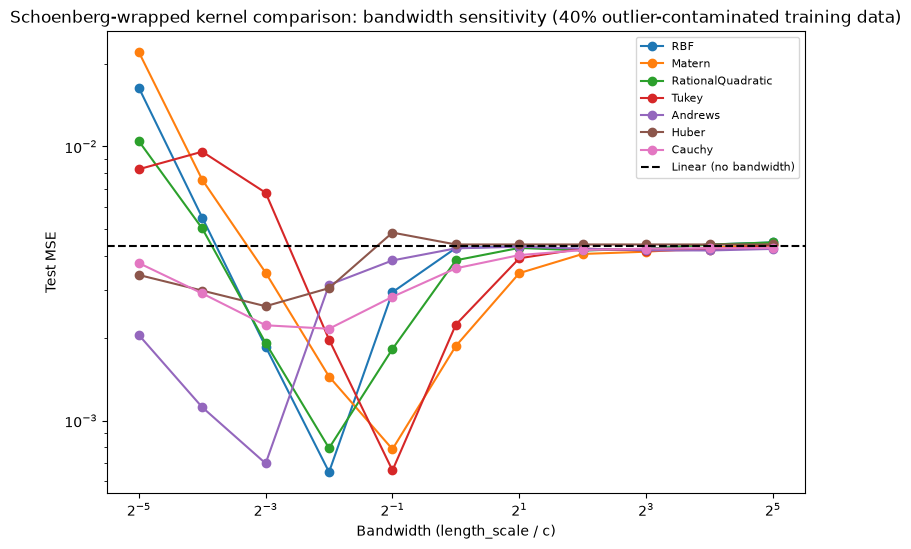

RBF
  bandwidth=   0.03125: MSE=0.01638
  bandwidth=   0.06250: MSE=0.00550
  bandwidth=   0.12500: MSE=0.00186
  bandwidth=   0.25000: MSE=0.00065
  bandwidth=   0.50000: MSE=0.00294
  bandwidth=   1.00000: MSE=0.00426
  bandwidth=   2.00000: MSE=0.00433
  bandwidth=   4.00000: MSE=0.00418
  bandwidth=   8.00000: MSE=0.00423
  bandwidth=  16.00000: MSE=0.00439
  bandwidth=  32.00000: MSE=0.00447
Matern
  bandwidth=   0.03125: MSE=0.02210
  bandwidth=   0.06250: MSE=0.00756
  bandwidth=   0.12500: MSE=0.00347
  bandwidth=   0.25000: MSE=0.00145
  bandwidth=   0.50000: MSE=0.00079
  bandwidth=   1.00000: MSE=0.00187
  bandwidth=   2.00000: MSE=0.00345
  bandwidth=   4.00000: MSE=0.00405
  bandwidth=   8.00000: MSE=0.00413
  bandwidth=  16.00000: MSE=0.00426
  bandwidth=  32.00000: MSE=0.00441
RationalQuadratic
  bandwidth=   0.03125: MSE=0.01046
  bandwidth=   0.06250: MSE=0.00502
  bandwidth=   0.12500: MSE=0.00192
  bandwidth=   0.25000: MSE=0.00079
  bandwidth=   0.50000: MSE=0.00183

In [8]:
# Schoenberg-wrapped kernel comparison: RBF, Matern, RationalQuadratic, Linear,
# and the four Schoenberg-wrapped robust kernels (Tukey, Andrews, Huber, Cauchy),
# on 40% outlier-contaminated training data.

np.random.seed(1)

num_train_samples = 50
contamination_fraction = 0.4

X = np.random.random(2000)
X = np.atleast_2d(X).T

y = f(X).ravel()
dy = 0.5 + 1.0 * np.random.random(y.shape[0])
noise = np.random.normal(0, dy)
y += noise

n_outliers = int(contamination_fraction * num_train_samples)
outlier_idx = np.random.choice(num_train_samples, n_outliers, replace=False)
y[outlier_idx] += np.random.choice([-1, 1], n_outliers) * np.random.uniform(8, 15, n_outliers)

scaler = MinMaxScaler((0.2, 0.8))
y = scaler.fit_transform(y.reshape(-1, 1)).ravel()

X_train, X_test = X[:num_train_samples], X[num_train_samples:]
y_train, y_test = y[:num_train_samples, None], y[num_train_samples:, None]

from sklearn.metrics import mean_squared_error

bandwidths = [2.0 ** k for k in range(-5, 6)]
gamma = 1.0

kernel_builders = {
    "RBF": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=bw),
    "Matern": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=bw, nu=1.5),
    "RationalQuadratic": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * RationalQuadratic(length_scale=bw, alpha=1.0),
    "Tukey": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Tukey(c=bw, gamma=gamma),
    "Andrews": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Andrews(c=bw, gamma=gamma),
    "Huber": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Huber(c=bw, gamma=gamma),
    "Cauchy": lambda bw: ConstantKernel(1.0, (1e-3, 1e3)) * Cauchy(c=bw, gamma=gamma),
}

results = {name: [] for name in kernel_builders}

for name, build_kernel in kernel_builders.items():
    for bw in bandwidths:
        kernel = build_kernel(bw)
        gp = GaussianProcessRegressor(kernel=kernel, alpha=0.15, optimizer=None)
        try:
            gp.fit(X_train, y_train)
            y_pred_test = gp.predict(X_test)
            mse = mean_squared_error(y_test, y_pred_test)
        except np.linalg.LinAlgError:
            mse = np.nan
        results[name].append(mse)

# Linear (DotProduct) kernel has no bandwidth/length_scale to sweep -- it's
# evaluated once and shown as a flat reference line instead.
linear_kernel = ConstantKernel(1.0, (1e-3, 1e3)) * DotProduct(sigma_0=1.0)
gp_linear = GaussianProcessRegressor(kernel=linear_kernel, alpha=0.15, optimizer=None)
gp_linear.fit(X_train, y_train)
linear_mse = mean_squared_error(y_test, gp_linear.predict(X_test))

plt.figure(figsize=(9, 6))
for name, mses in results.items():
    plt.plot(bandwidths, mses, marker='o', label=name)
plt.axhline(linear_mse, color='black', linestyle='--', label='Linear (no bandwidth)')

plt.xscale('log', base=2)
plt.yscale('log')
plt.xlabel('Bandwidth (length_scale / c)')
plt.ylabel('Test MSE')
plt.title('Schoenberg-wrapped kernel comparison: bandwidth sensitivity (40% outlier-contaminated training data)')
plt.legend(fontsize=8)
plt.show()

for name, mses in results.items():
    print(name)
    for bw, mse in zip(bandwidths, mses):
        mse_str = f"{mse:.5f}" if not np.isnan(mse) else "nan (singular kernel matrix)"
        print(f"  bandwidth={bw:>10.5f}: MSE={mse_str}")

print(f"Linear (no bandwidth): MSE={linear_mse:.5f}")